In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import shap

with open('models/best_model.pkl', 'rb') as f:
    model = pickle.load(f)
with open('models/scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

# Reload data exactly as Day 1 prepared it — re-run cleaning steps
df = pd.read_csv('data/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)
df.drop(columns=['customerID'], inplace=True)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

cat_cols = df.select_dtypes(include='object').columns.tolist()
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

from sklearn.model_selection import train_test_split
X = df_encoded.drop(columns=['Churn'])
y = df_encoded['Churn']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
X_test[num_cols] = scaler.transform(X_test[num_cols])

print("Loaded model and test data")
print("Test shape:", X_test.shape)

Loaded model and test data
Test shape: (1409, 30)


Data types:
float64    30
Name: count, dtype: int64
SHAP values generated successfully
Shape: (1409, 30)


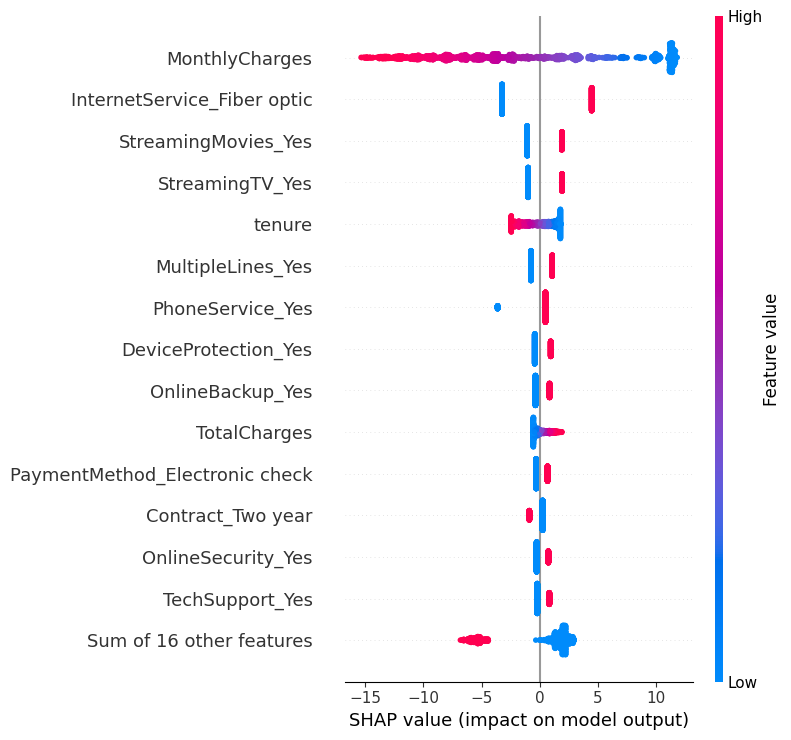

In [18]:
# SHAP Analysis (safe version)

import shap
import numpy as np

# Ensure all columns are numeric
X_test = X_test.astype(float)

print("Data types:")
print(X_test.dtypes.value_counts())

# Create explainer
explainer = shap.LinearExplainer(model, X_test)

# Generate SHAP values
shap_values = explainer(X_test)

print("SHAP values generated successfully")
print("Shape:", shap_values.values.shape)

# SHAP summary plot
shap.plots.beeswarm(shap_values, max_display=15, show=False)

plt.tight_layout()
plt.savefig('assets/shap_summary.png', bbox_inches='tight')
plt.show()

Top 10 features driving churn predictions:
                    feature  mean_abs_shap
             MonthlyCharges       7.265240
InternetService_Fiber optic       3.775276
        StreamingMovies_Yes       1.383801
            StreamingTV_Yes       1.332265
                     tenure       1.296927
          MultipleLines_Yes       0.885095
           PhoneService_Yes       0.766174
       DeviceProtection_Yes       0.601679
           OnlineBackup_Yes       0.517856
               TotalCharges       0.514788


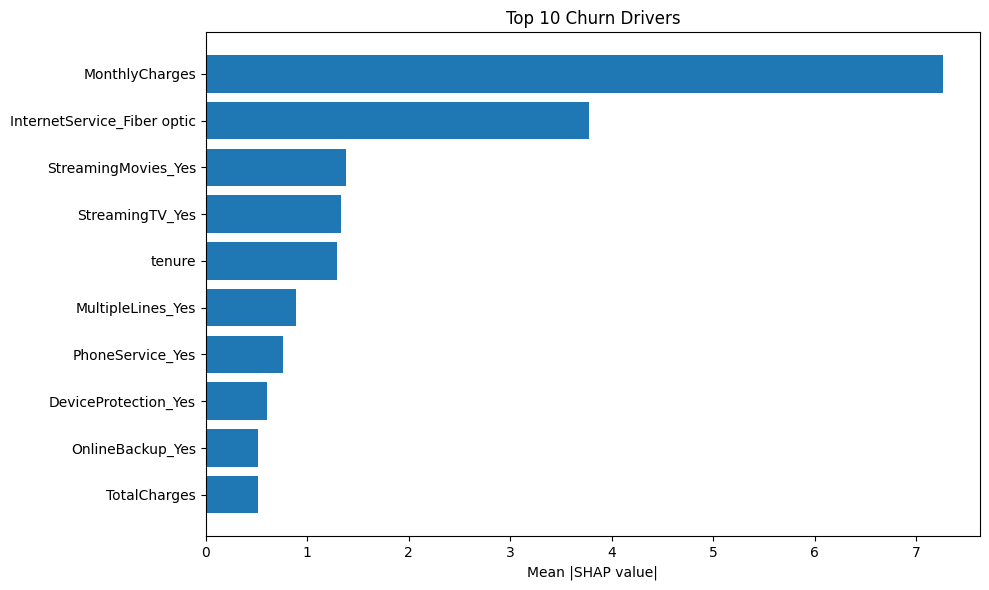

In [19]:
mean_abs_shap = pd.DataFrame({
    'feature': X_test.columns,
    'mean_abs_shap': np.abs(shap_values.values).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False)

print("Top 10 features driving churn predictions:")
print(mean_abs_shap.head(10).to_string(index=False))

plt.figure(figsize=(10, 6))
plt.barh(
    mean_abs_shap['feature'][:10],
    mean_abs_shap['mean_abs_shap'][:10]
)
plt.xlabel('Mean |SHAP value|')
plt.title('Top 10 Churn Drivers')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('assets/shap_top_features.png')
plt.show()

In [20]:
# Get predicted probabilities for test set
probs = model.predict_proba(X_test)[:, 1]

# Find 3 highest-risk customers
high_risk_idx = np.argsort(probs)[-3:][::-1]

for rank, idx in enumerate(high_risk_idx, 1):

    print(f"\n{'='*50}")
    print(f"High-Risk Customer #{rank}")
    print(f"Predicted churn probability: {probs[idx]:.2%}")
    print(f"Actual outcome: {'Churned' if y_test.iloc[idx] == 1 else 'Did not churn'}")

    customer_shap = pd.DataFrame({
        'feature': X_test.columns,
        'shap_value': shap_values.values[idx]
    })

    customer_shap['abs_shap'] = customer_shap['shap_value'].abs()

    customer_shap = customer_shap.sort_values(
        'abs_shap',
        ascending=False
    )

    print("\nTop factors driving this prediction:")
    print(
        customer_shap[['feature', 'shap_value']]
        .head(3)
        .to_string(index=False)
    )


High-Risk Customer #1
Predicted churn probability: 94.41%
Actual outcome: Did not churn

Top factors driving this prediction:
                    feature  shap_value
             MonthlyCharges   -9.095436
InternetService_Fiber optic    4.472257
            StreamingTV_Yes    1.926132

High-Risk Customer #2
Predicted churn probability: 94.07%
Actual outcome: Churned

Top factors driving this prediction:
                    feature  shap_value
             MonthlyCharges   -7.509424
InternetService_Fiber optic    4.472257
            StreamingTV_Yes    1.926132

High-Risk Customer #3
Predicted churn probability: 93.68%
Actual outcome: Churned

Top factors driving this prediction:
                    feature  shap_value
             MonthlyCharges  -11.398602
InternetService_Fiber optic    4.472257
            StreamingTV_Yes    1.926132


In [33]:
business_insight = """
Business Insight: Optimal Threshold is Cost-Dependent

At the assumed $50 retention offer cost, the model suggests a low
threshold (0.20) — targeting a broad set of at-risk customers is
profitable because the offer is cheap relative to customer lifetime
value (~$1,500+), even accounting for false positives.

As offer cost increases, the optimal strategy shifts toward higher
thresholds — being more selective and targeting only high-confidence
churners, since false positives become more expensive to absorb.

This demonstrates that there is no single "correct" classification
threshold — the right operating point depends on the actual cost
structure of the retention program, which should be confirmed with
real business data before deployment, not assumed.
"""
print(business_insight)


Business Insight: Optimal Threshold is Cost-Dependent

At the assumed $50 retention offer cost, the model suggests a low
threshold (0.20) — targeting a broad set of at-risk customers is
profitable because the offer is cheap relative to customer lifetime
value (~$1,500+), even accounting for false positives.

As offer cost increases, the optimal strategy shifts toward higher
thresholds — being more selective and targeting only high-confidence
churners, since false positives become more expensive to absorb.

This demonstrates that there is no single "correct" classification
threshold — the right operating point depends on the actual cost
structure of the retention program, which should be confirmed with
real business data before deployment, not assumed.



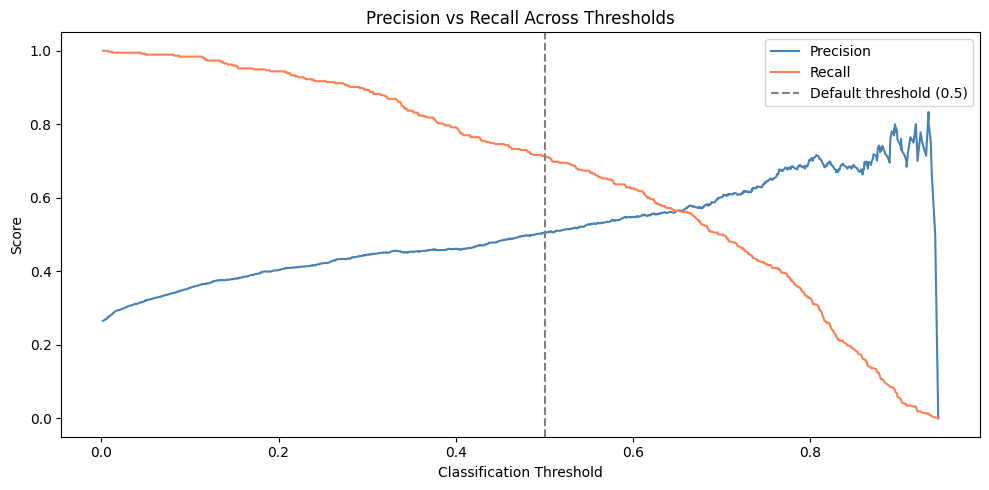

In [22]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_test, probs)

plt.figure(figsize=(10, 5))
plt.plot(thresholds, precisions[:-1], label='Precision', color='steelblue')
plt.plot(thresholds, recalls[:-1], label='Recall', color='coral')
plt.axvline(x=0.5, color='gray', linestyle='--', label='Default threshold (0.5)')
plt.xlabel('Classification Threshold')
plt.ylabel('Score')
plt.title('Precision vs Recall Across Thresholds')
plt.legend()
plt.tight_layout()
plt.savefig('assets/threshold_tuning.png')
plt.show()

In [23]:
explanation = """
Why not just use the default 0.5 threshold?

Lowering the threshold below 0.5 catches more churners (higher recall)
but flags more false positives (lower precision) — meaning more 
retention offers go to customers who weren't actually going to leave.

Raising the threshold above 0.5 does the opposite — fewer wasted 
offers, but more actual churners slip through undetected.

The "right" threshold depends on the relative cost of each error type,
which is a business decision, not a purely statistical one.
"""
print(explanation)


Why not just use the default 0.5 threshold?

Lowering the threshold below 0.5 catches more churners (higher recall)
but flags more false positives (lower precision) — meaning more 
retention offers go to customers who weren't actually going to leave.

Raising the threshold above 0.5 does the opposite — fewer wasted 
offers, but more actual churners slip through undetected.

The "right" threshold depends on the relative cost of each error type,
which is a business decision, not a purely statistical one.



In [24]:
# These are reasonable, stated assumptions — adjust if you have better numbers
avg_monthly_revenue = df['MonthlyCharges'].mean()
avg_customer_lifetime_months = 24  # assumption: avg customer stays 2 more years if retained
customer_ltv = avg_monthly_revenue * avg_customer_lifetime_months

retention_offer_cost = 50  # assumption: cost of a discount/offer per customer
retention_success_rate = 0.30  # assumption: 30% of offered customers who were going to churn, stay

print(f"Average monthly revenue per customer: ${avg_monthly_revenue:.2f}")
print(f"Assumed customer lifetime value if retained: ${customer_ltv:.2f}")
print(f"Assumed retention offer cost: ${retention_offer_cost}")
print(f"Assumed retention success rate: {retention_success_rate:.0%}")

Average monthly revenue per customer: $64.76
Assumed customer lifetime value if retained: $1554.28
Assumed retention offer cost: $50
Assumed retention success rate: 30%


In [25]:
results_by_threshold = []

for t in np.arange(0.2, 0.8, 0.05):
    preds_t = (probs >= t).astype(int)

    tp = ((preds_t == 1) & (y_test == 1)).sum()  # correctly flagged churners
    fp = ((preds_t == 1) & (y_test == 0)).sum()  # wasted offers

    total_offer_cost = (tp + fp) * retention_offer_cost
    total_revenue_saved = tp * retention_success_rate * customer_ltv
    net_value = total_revenue_saved - total_offer_cost

    results_by_threshold.append({
        'threshold': round(t, 2),
        'customers_targeted': tp + fp,
        'true_churners_caught': tp,
        'false_positives': fp,
        'total_cost': round(total_offer_cost, 2),
        'revenue_saved': round(total_revenue_saved, 2),
        'net_value': round(net_value, 2)
    })

threshold_results = pd.DataFrame(results_by_threshold)
print(threshold_results.to_string(index=False))

best_threshold_row = threshold_results.loc[threshold_results['net_value'].idxmax()]
print(f"\nOptimal threshold for max net value: {best_threshold_row['threshold']}")
print(f"Net value at optimal threshold: ${best_threshold_row['net_value']:.2f}")

 threshold  customers_targeted  true_churners_caught  false_positives  total_cost  revenue_saved  net_value
      0.20                 875                   353              522       43750      164598.32  120848.32
      0.25                 813                   343              470       40650      159935.48  119285.48
      0.30                 750                   334              416       37500      155738.92  118238.92
      0.35                 690                   313              377       34500      145946.95  111446.95
      0.40                 642                   296              346       32100      138020.12  105920.12
      0.45                 577                   279              298       28850      130093.29  101243.29
      0.50                 527                   266              261       26350      124031.59   97681.59
      0.55                 476                   251              225       23800      117037.33   93237.33
      0.60                 4

In [31]:
results_extended = []

for t in np.arange(0.05, 0.85, 0.05):

    preds_t = (probs >= t).astype(int)

    tp = ((preds_t == 1) & (y_test == 1)).sum()
    fp = ((preds_t == 1) & (y_test == 0)).sum()

    total_offer_cost = (tp + fp) * retention_offer_cost
    total_revenue_saved = tp * retention_success_rate * customer_ltv
    net_value = total_revenue_saved - total_offer_cost

    results_extended.append({
        'threshold': round(t, 2),
        'net_value': round(net_value, 2)
    })

ext_df = pd.DataFrame(results_extended)

print(ext_df.to_string(index=False))

 threshold  net_value
      0.05  114725.15
      0.10  119792.58
      0.15  120196.02
      0.20  120848.32
      0.25  119285.48
      0.30  118238.92
      0.35  111446.95
      0.40  105920.12
      0.45  101243.29
      0.50   97681.59
      0.55   93237.33
      0.60   87760.50
      0.65   79735.96
      0.70   71695.14
      0.75   61006.62
      0.80   48236.67


In [32]:
threshold_grid = np.arange(0.2, 0.85, 0.1)

for cost in [50, 100, 150, 200]:

    results_sens = []

    for t in threshold_grid:

        preds_t = (probs >= t).astype(int)

        tp = ((preds_t == 1) & (y_test == 1)).sum()
        fp = ((preds_t == 1) & (y_test == 0)).sum()

        net_value = (
            tp * retention_success_rate * customer_ltv
        ) - (
            (tp + fp) * cost
        )

        results_sens.append(net_value)

    best_t = threshold_grid[np.argmax(results_sens)]

    print(
        f"Offer cost ${cost} -> "
        f"optimal threshold ≈ {best_t:.2f}, "
        f"max net value ${max(results_sens):,.2f}"
    )

Offer cost $50 -> optimal threshold ≈ 0.20, max net value $120,848.32
Offer cost $100 -> optimal threshold ≈ 0.30, max net value $80,738.92
Offer cost $150 -> optimal threshold ≈ 0.60, max net value $45,060.50
Offer cost $200 -> optimal threshold ≈ 0.70, max net value $25,195.14


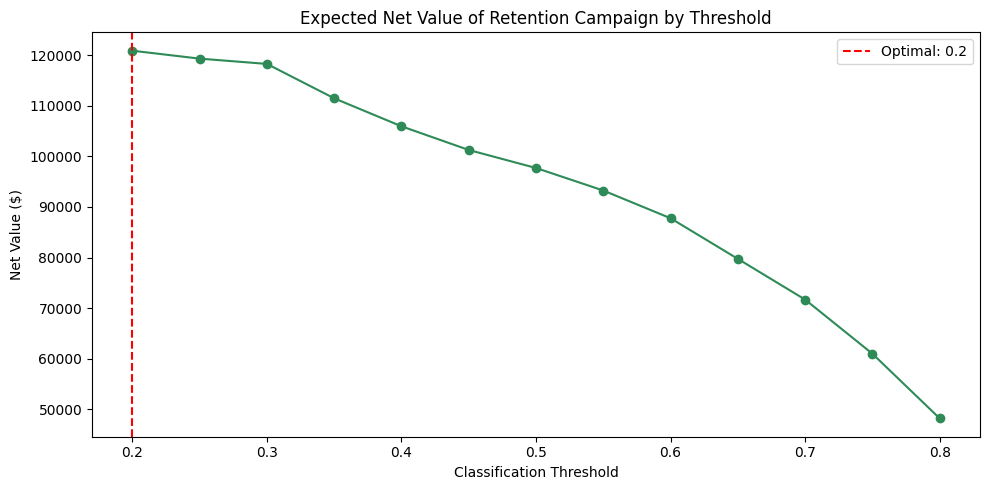

In [26]:
plt.figure(figsize=(10, 5))
plt.plot(threshold_results['threshold'], threshold_results['net_value'],
         marker='o', color='seagreen')
plt.axvline(x=best_threshold_row['threshold'], color='red', linestyle='--',
            label=f"Optimal: {best_threshold_row['threshold']}")
plt.xlabel('Classification Threshold')
plt.ylabel('Net Value ($)')
plt.title('Expected Net Value of Retention Campaign by Threshold')
plt.legend()
plt.tight_layout()
plt.savefig('assets/business_value_threshold.png')
plt.show()

In [27]:
threshold_results.to_csv('assets/threshold_business_analysis.csv', index=False)
print("Saved business impact analysis")

Saved business impact analysis


In [28]:
# Check scaling
print(X_test[['tenure', 'MonthlyCharges', 'TotalCharges']].describe())

            tenure  MonthlyCharges  TotalCharges
count  1409.000000     1409.000000   1409.000000
mean     -0.023184       -0.027911     -0.042990
std       0.998342        0.992131      0.972154
min      -1.322329       -1.549006     -1.008922
25%      -0.996684       -0.986545     -0.850914
50%      -0.182569        0.166583     -0.397009
75%       0.916486        0.813661      0.534693
max       1.608483        1.721231      2.719333


In [29]:
coef_df = pd.DataFrame({
    'feature': X_test.columns,
    'coefficient': model.coef_[0]
}).sort_values('coefficient')

print("Most negative coefficients:")
print(coef_df.head(10).to_string(index=False))

print("\nMost positive coefficients:")
print(coef_df.tail(10).to_string(index=False))

Most negative coefficients:
                             feature  coefficient
                      MonthlyCharges    -8.312202
                              tenure    -1.461206
                   Contract_Two year    -1.141124
  OnlineSecurity_No internet service    -1.042100
    OnlineBackup_No internet service    -1.042100
 StreamingMovies_No internet service    -1.042100
DeviceProtection_No internet service    -1.042100
                  InternetService_No    -1.042100
     TechSupport_No internet service    -1.042100
     StreamingTV_No internet service    -1.042100

Most positive coefficients:
                       feature  coefficient
PaymentMethod_Electronic check     0.978551
            OnlineSecurity_Yes     1.005352
               TechSupport_Yes     1.035319
              OnlineBackup_Yes     1.209848
          DeviceProtection_Yes     1.374213
             MultipleLines_Yes     1.827866
               StreamingTV_Yes     2.918382
           StreamingMovies_Yes     2.9751

In [30]:
# Check correlation between MonthlyCharges and the fiber/streaming flags
print(X_test[['MonthlyCharges']].join(
    df_encoded[['InternetService_Fiber optic', 'StreamingTV_Yes']]
).corr())

                             MonthlyCharges  InternetService_Fiber optic  \
MonthlyCharges                     1.000000                     0.784891   
InternetService_Fiber optic        0.784891                     1.000000   
StreamingTV_Yes                    0.621388                     0.323740   

                             StreamingTV_Yes  
MonthlyCharges                      0.621388  
InternetService_Fiber optic         0.323740  
StreamingTV_Yes                     1.000000  


In [34]:
threshold_grid = np.arange(0.2, 0.85, 0.1)

results_summary = []

for cost in [50, 100, 150, 200]:

    results_sens = []

    for t in threshold_grid:

        preds_t = (probs >= t).astype(int)

        tp = ((preds_t == 1) & (y_test == 1)).sum()
        fp = ((preds_t == 1) & (y_test == 0)).sum()

        net_value = (
            tp * retention_success_rate * customer_ltv
        ) - (
            (tp + fp) * cost
        )

        results_sens.append(net_value)

    best_t = threshold_grid[np.argmax(results_sens)]
    best_value = max(results_sens)

    results_summary.append({
        "offer_cost": cost,
        "optimal_threshold": best_t,
        "max_net_value": best_value
    })

    print(
        f"Offer cost ${cost} -> "
        f"optimal threshold ≈ {best_t:.2f}, "
        f"max net value ${best_value:,.2f}"
    )

Offer cost $50 -> optimal threshold ≈ 0.20, max net value $120,848.32
Offer cost $100 -> optimal threshold ≈ 0.30, max net value $80,738.92
Offer cost $150 -> optimal threshold ≈ 0.60, max net value $45,060.50
Offer cost $200 -> optimal threshold ≈ 0.70, max net value $25,195.14


In [35]:
sensitivity_df = pd.DataFrame(results_summary)

sensitivity_df.to_csv(
    'assets/threshold_sensitivity_analysis.csv',
    index=False
)

print("Saved sensitivity analysis")

Saved sensitivity analysis
